## Etapa 1 - Importando Bibliotecas

In [1]:
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless
!pip install opencv-python==4.10.0.84

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
Found existing installation: opencv-contrib-python 4.14.0.94
Uninstalling opencv-contrib-python-4.14.0.94:
  Successfully uninstalled opencv-contrib-python-4.14.0.94
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 11.3 MB/s eta 0:00:00


In [2]:
import cv2
import numpy as np
import pandas as pd
from google.colab.patches import cv2_imshow
import zipfile

In [3]:
%tensorflow_version 2.x

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [4]:
import tensorflow
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
tensorflow.__version__

'2.20.0'

In [5]:
import matplotlib.pyplot as plt

In [6]:
!pip install tf_keras

## Etapa 2 - Conectando com o Drive e acessando os arquivos

In [7]:
from google.colab import drive
drive.mount('/content/gdrive') # Conecta o Google Drive ao ambiente do Colab

Mounted at /content/gdrive


In [8]:
path = "/content/gdrive/MyDrive/Colab Notebooks/Card 23/aula/Material.zip"  # Define o caminho do arquivo ZIP no Google Drive
zip_object = zipfile.ZipFile(file=path, mode="r")  # Abre o arquivo ZIP em modo de leitura
zip_object.extractall('./')  # Extrai todos os arquivos para o diretório atual
zip_object.close  # Fecha o arquivo ZIP

<bound method ZipFile.close of <zipfile.ZipFile filename='/content/gdrive/MyDrive/Colab Notebooks/Card 23/aula/Material.zip' mode='r'>>

In [9]:
base_imgs = '/content/gdrive/MyDrive/Colab Notebooks/Card 23/aula/fer_images.zip'  # Define o caminho do arquivo ZIP com as imagens
zip_object = zipfile.ZipFile(file=base_imgs, mode="r")  # Abre o arquivo ZIP em modo de leitura
zip_object.extractall('./')  # Extrai todos os arquivos para o diretório atual
zip_object.close  # Fecha o arquivo ZIP

<bound method ZipFile.close of <zipfile.ZipFile filename='/content/gdrive/MyDrive/Colab Notebooks/Card 23/aula/fer_images.zip' mode='r'>>

## Etapa 3 - Acessando a base com fotos de expressoes faciais

In [10]:
data = pd.read_csv('fer2013/fer2013.csv') # carregamento do csv
data.tail()

,emotion,pixels,Usage
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest
35886,2,19 13 14 12 13 16 21 33 50 57 71 84 97 108 122...,PrivateTest


Text(0.5, 1.0, 'Imagens X Emoções')

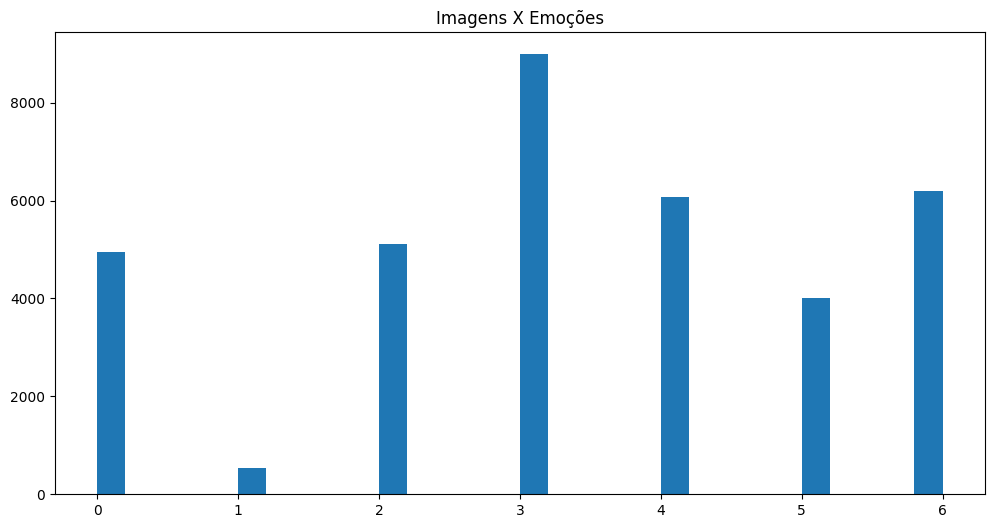

In [11]:
plt.figure(figsize=(12,6))
plt.hist(data['emotion'], bins=30) # 7 colunas
plt.title('Imagens X Emoções') # titulo

# classes: ['Raiva', 'Nojo', 'Triste', 'Feliz', 'Surpreso', 'Neutro']

## Etapa 4 - Pré-processamento

In [12]:
pixels = data['pixels'].tolist() # convertendo para uma lista
pixels

Output hidden; open in https://colab.research.google.com to view.

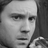

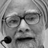

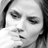

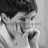

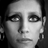

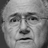

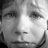

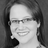

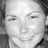

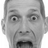

In [13]:
largura, altura = 48, 48 # dimensao
faces = []
amostras = 0
for pixel_sequence in pixels:
  face = [int(pixel) for pixel in pixel_sequence.split(' ')] # vai jogar cada um dos valores da string em pixel separa por espaço (' ')
  face = np.array(face).reshape(largura, altura) # transformando em um array e um reshape para 48x48
  faces.append(face) # colocando no formato do numpy array

  if (amostras < 10): # mostra as 10 primeiras imagens
    cv2_imshow(face)
  amostras += 1

In [14]:
print('Numero total de imagens no Dataset:', str(len(faces)))

Numero total de imagens no Dataset: 35887


In [15]:
faces = np.asarray(faces)  # Converte a variável faces para um array

In [16]:
faces.shape

(35887, 48, 48)

In [17]:
faces = np.expand_dims(faces, -1) # expandir as dimensoes
faces.shape

(35887, 48, 48, 1)

In [18]:
def normalizar(x): # normalizando dados
  x = x.astype('float32')
  x = x / 255.0
  return x

In [19]:
faces = normalizar(faces) # normalizando

In [20]:
faces[0]

array([[[0.27450982],
        [0.3137255 ],
        [0.32156864],
        ...,
        [0.20392157],
        [0.16862746],
        [0.16078432]],

       [[0.25490198],
        [0.23921569],
        [0.22745098],
        ...,
        [0.21960784],
        [0.20392157],
        [0.17254902]],

       [[0.19607843],
        [0.16862746],
        [0.21176471],
        ...,
        [0.19215687],
        [0.21960784],
        [0.18431373]],

       ...,

       [[0.35686275],
        [0.25490198],
        [0.16470589],
        ...,
        [0.28235295],
        [0.21960784],
        [0.16862746]],

       [[0.3019608 ],
        [0.32156864],
        [0.30980393],
        ...,
        [0.4117647 ],
        [0.27450982],
        [0.18039216]],

       [[0.3019608 ],
        [0.28235295],
        [0.32941177],
        ...,
        [0.41568628],
        [0.42745098],
        [0.32156864]]], dtype=float32)

In [21]:
emocoes = pd.get_dummies(data['emotion']).values  # Converte as emoções em variáveis binárias

In [22]:
emocoes[0]

array([ True, False, False, False, False, False, False])

## Etapa 5 - Imports do Tensorflow/Keras

In [23]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from tensorflow.keras.models import model_from_json

## Etapa 6 - Dividir em conjuntos para treinamento e validação

In [24]:
x_train, x_test, y_train, y_test = train_test_split(faces, emocoes, test_size=0.1, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=41)

In [25]:
print('Numero de imagens no conjunto de treinamento: ',len(x_train))
print('Numero de imagens no conjunto de teste: ',len(x_test))
print('Numero de imagens no conjunto de validação: ',len(x_val))

Numero de imagens no conjunto de treinamento:  29068
Numero de imagens no conjunto de teste:  3589
Numero de imagens no conjunto de validação:  3230


In [26]:
# salvar a base de dados
np.save('mod_xtest', x_test)
np.save('mod_ytest', y_test)

## Etapa 7 - Arquitetura do modelo (CNN)

In [27]:
num_features = 32
num_classes = 7
batch_size = 16
epochs = 100
width, height = 48, 48

# Criação do modelo
model = Sequential()

# Primeiro bloco convolucional
model.add(Conv2D(num_features, (3,3), padding='same', kernel_initializer='he_normal',
                 input_shape=(width, height, 1)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(num_features, (3,3), padding='same', kernel_initializer='he_normal',
                 input_shape=(width, height, 1)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# Segundo bloco convolucional
model.add(Conv2D(2*num_features, (3,3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(2*num_features, (3,3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# Terceiro bloco convolucional
model.add(Conv2D(2*2*num_features, (3,3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(2*2*num_features, (3,3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# Quarto bloco convolucional
model.add(Conv2D(2*2*2*num_features, (3,3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(2*2*2*num_features, (3,3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# Camadas densas para classificação
model.add(Flatten())
model.add(Dense(2*num_features, kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(2*num_features, kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Camada de saída para as 7 emoções
model.add(Dense(num_classes, kernel_initializer='he_normal'))
model.add(Dense(num_classes, activation='softmax'))

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,328,223 (5.07 MB)

 Trainable params: 1,326,047 (5.06 MB)

 Non-trainable params: 2,176 (8.50 KB)

## Etapa 8 - Compilando o Modelo

In [28]:
model.compile(loss='categorical_crossentropy',
              optimizer = Adam(learning_rate=0.001, beta_1=0.9,beta_2=0.999, epsilon=1e-7),
              metrics=['accuracy']) # configurando o compile
arquivo_modelo = 'modelo_01_expressoes.h5' # arquivo do modelo
arquivo_modelo_json = 'modelo_01_expressoes.json' # arquivo do modelo json
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.9, patience=3, verbose=1) # aplicar o reducer
early_stopper = EarlyStopping(monitor='val_loss', min_delta=0, patience=8, verbose=1, mode='auto') # aplicar o early stopper
checkpointer = ModelCheckpoint(arquivo_modelo, monitor='val_loss', verbose=1, save_best_only=True) # aplicar o checkpointer, salvando o modelo

## Salvando a arquitetura do modelo em um arquivo JSON

In [29]:
model_json = model.to_json() # salvando o modelo em um arquivo json
with open(arquivo_modelo_json, 'w') as json_file: # abrindo o arquivo para salvar
  json_file.write(model_json)

## Etapa 9 - Treinando o modelo

In [30]:
history = model.fit(np.array(x_train), np.array(y_train),
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(np.array(x_val), np.array(y_val)),
                    shuffle=True,
                    callbacks=[lr_reducer, checkpointer, early_stopper]) # iniciando o treinamento

Epoch 1/100
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2543 - loss: 2.0615
Epoch 1: val_loss improved from None to 1.40266, saving model to modelo_01_expressoes.h5



Epoch 1: finished saving model to modelo_01_expressoes.h5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 48s 16ms/step - accuracy: 0.3212 - loss: 1.7797 - val_accuracy: 0.4560 - val_loss: 1.4027 - learning_rate: 0.0010
Epoch 2/100
1812/1817 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4309 - loss: 1.4728
Epoch 2: val_loss improved from 1.40266 to 1.26504, saving model to modelo_01_expressoes.h5



Epoch 2: finished saving model to modelo_01_expressoes.h5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.4475 - loss: 1.4327 - val_accuracy: 0.5136 - val_loss: 1.2650 - learning_rate: 0.0010
Epoch 3/100
1813/1817 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4874 - loss: 1.3362
Epoch 3: val_loss improved from 1.26504 to 1.22281, saving model to modelo_01_expressoes.h5



Epoch 3: finished saving model to modelo_01_expressoes.h5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.4992 - loss: 1.3230 - val_accuracy: 0.5350 - val_loss: 1.2228 - learning_rate: 0.0010
Epoch 4/100
1814/1817 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5320 - loss: 1.2530
Epoch 4: val_loss improved from 1.22281 to 1.10024, saving model to modelo_01_expressoes.h5



Epoch 4: finished saving model to modelo_01_expressoes.h5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.5326 - loss: 1.2525 - val_accuracy: 0.5879 - val_loss: 1.1002 - learning_rate: 0.0010
Epoch 5/100
1815/1817 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5536 - loss: 1.1985
Epoch 5: val_loss did not improve from 1.10024
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.5597 - loss: 1.1877 - val_accuracy: 0.5892 - val_loss: 1.1040 - learning_rate: 0.0010
Epoch 6/100
1815/1817 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5911 - loss: 1.1230
Epoch 6: val_loss improved from 1.10024 to 1.04681, saving model to modelo_01_expressoes.h5



Epoch 6: finished saving model to modelo_01_expressoes.h5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.5868 - loss: 1.1327 - val_accuracy: 0.6124 - val_loss: 1.0468 - learning_rate: 0.0010
Epoch 7/100
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6073 - loss: 1.0683
Epoch 7: val_loss did not improve from 1.04681
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.6049 - loss: 1.0803 - val_accuracy: 0.6102 - val_loss: 1.0480 - learning_rate: 0.0010
Epoch 8/100
1813/1817 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6323 - loss: 1.0167
Epoch 8: val_loss improved from 1.04681 to 1.01338, saving model to modelo_01_expressoes.h5



Epoch 8: finished saving model to modelo_01_expressoes.h5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.6280 - loss: 1.0261 - val_accuracy: 0.6353 - val_loss: 1.0134 - learning_rate: 0.0010
Epoch 9/100
1813/1817 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6571 - loss: 0.9582
Epoch 9: val_loss improved from 1.01338 to 1.00890, saving model to modelo_01_expressoes.h5



Epoch 9: finished saving model to modelo_01_expressoes.h5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.6539 - loss: 0.9701 - val_accuracy: 0.6393 - val_loss: 1.0089 - learning_rate: 0.0010
Epoch 10/100
1816/1817 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6797 - loss: 0.9076
Epoch 10: val_loss improved from 1.00890 to 0.99280, saving model to modelo_01_expressoes.h5



Epoch 10: finished saving model to modelo_01_expressoes.h5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.6735 - loss: 0.9209 - val_accuracy: 0.6464 - val_loss: 0.9928 - learning_rate: 0.0010
Epoch 11/100
1816/1817 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6983 - loss: 0.8546
Epoch 11: val_loss did not improve from 0.99280
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.6926 - loss: 0.8703 - val_accuracy: 0.6421 - val_loss: 1.0213 - learning_rate: 0.0010
Epoch 12/100
1816/1817 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7134 - loss: 0.8112
Epoch 12: val_loss did not improve from 0.99280
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.7094 - loss: 0.8208 - val_accuracy: 0.6483 - val_loss: 1.0090 - learning_rate: 0.0010
Epoch 13/100
1812/1817 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7382 - loss: 0.7550
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0009000000427477062.

Epoch 13: val_loss did not improve from 0.99280
1817/1817 ━━━━━━

In [31]:
print(history.history) # mostra o historico dos resultados

{'accuracy': [0.3212467432022095, 0.44753679633140564, 0.4992431402206421, 0.5326131582260132, 0.5597220063209534, 0.5867620706558228, 0.6049264073371887, 0.6279757618904114, 0.6539149284362793, 0.6734553575515747, 0.6926172971725464, 0.7094055414199829, 0.7332117557525635, 0.7573620676994324, 0.7724301815032959, 0.789080798625946, 0.8081051111221313, 0.8207650780677795], 'loss': [1.779748558998108, 1.4327473640441895, 1.3229855298995972, 1.2524746656417847, 1.1877080202102661, 1.1326794624328613, 1.0803213119506836, 1.0261297225952148, 0.9701461791992188, 0.9209375977516174, 0.8703241944313049, 0.8208016753196716, 0.7692057490348816, 0.7104101777076721, 0.6672144532203674, 0.6244045495986938, 0.5718666315078735, 0.5354648232460022], 'val_accuracy': [0.45603716373443604, 0.5136222839355469, 0.5349845290184021, 0.5879256725311279, 0.5891640782356262, 0.6123839020729065, 0.6102167367935181, 0.6352941393852234, 0.6393188834190369, 0.6464396119117737, 0.6421052813529968, 0.6482971906661987

## Gerando o gráfico da melhora em cada etapa do treinamento

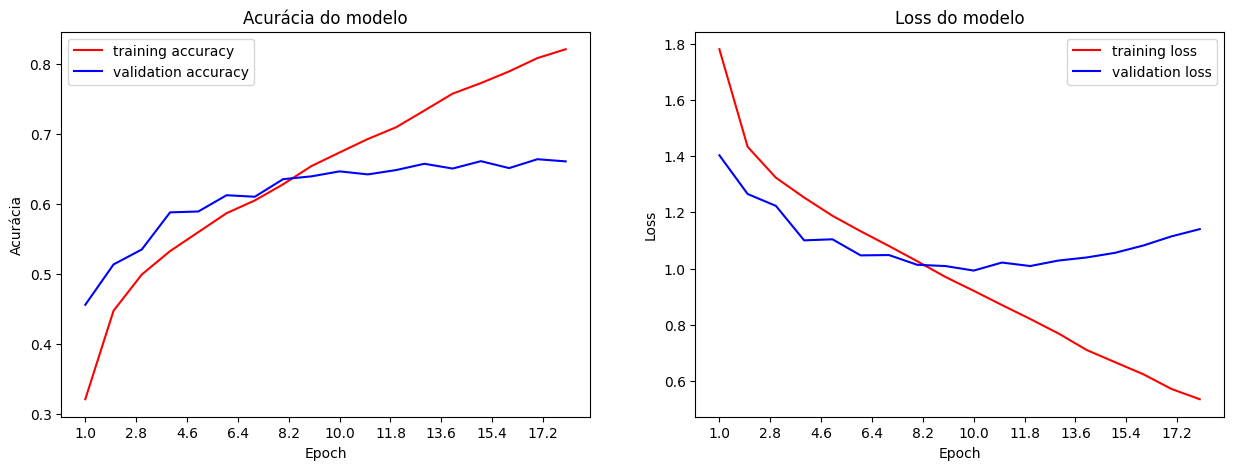

In [32]:
def plota_historico_modelo(historico_modelo):
  fig, axs = plt.subplots(1, 2, figsize=(15,5))
  axs[0].plot(range(1, len(historico_modelo.history['accuracy']) + 1), historico_modelo.history['accuracy'], 'r') # plot da acuracia
  axs[0].plot(range(1, len(historico_modelo.history['val_accuracy']) + 1), historico_modelo.history['val_accuracy'], 'b') # plot do val_accuracy
  axs[0].set_title('Acurácia do modelo') # titulo
  axs[0].set_ylabel('Acurácia') # eixo y
  axs[0].set_xlabel('Epoch') # eixo x
  axs[0].set_xticks(np.arange(1,len(historico_modelo.history['accuracy']) + 1,
        len(historico_modelo.history['accuracy']) / 10))
  axs[0].legend(['training accuracy', 'validation accuracy'], loc='best') # legenda

  axs[1].plot(range(1, len(historico_modelo.history['loss']) + 1), historico_modelo.history['loss'], 'r') # plot do loss
  axs[1].plot(range(1, len(historico_modelo.history['val_loss']) + 1), historico_modelo.history['val_loss'], 'b') # plot do val_loss
  axs[1].set_title('Loss do modelo') # titulo
  axs[1].set_ylabel('Loss') # eixo y
  axs[1].set_xlabel('Epoch') # eixo x
  axs[1].set_xticks(np.arange(1,len(historico_modelo.history['loss']) + 1,
        len(historico_modelo.history['loss']) / 10))
  axs[1].legend(['training loss', 'validation loss'], loc='best') # legenda
  fig.savefig('historico_modelo_mod01.png') # salvar a figura

plota_historico_modelo(history)

## Verificando a acurácia do modelo

In [33]:
scores = model.evaluate(np.array(x_test), np.array(y_test), batch_size=batch_size) # fazendo avaliação do modelo

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6434 - loss: 1.1898


In [34]:
scores

[1.1898194551467896, 0.6433547139167786]

In [35]:
print('Acurácia: ' + str(scores[1]))
print('Erro: ' + str(scores[0]))

Acurácia: 0.6433547139167786
Erro: 1.1898194551467896


## Carregamento dos dados para gerar a matriz de confusão

In [36]:
true_y = [] # recebe as respostas reais
pred_y = [] # recebe as respostas das previsoes
x = np.load('mod_xtest.npy') # carregando o x_test
y = np.load('mod_ytest.npy') # carregando o y_test

In [37]:
x[0]

array([[[0.5568628 ],
        [0.5803922 ],
        [0.59607846],
        ...,
        [0.3529412 ],
        [0.3529412 ],
        [0.3647059 ]],

       [[0.5568628 ],
        [0.5764706 ],
        [0.5921569 ],
        ...,
        [0.33333334],
        [0.36078432],
        [0.40392157]],

       [[0.5529412 ],
        [0.5686275 ],
        [0.5921569 ],
        ...,
        [0.3372549 ],
        [0.32156864],
        [0.37254903]],

       ...,

       [[0.0627451 ],
        [0.08235294],
        [0.07058824],
        ...,
        [0.08235294],
        [0.09019608],
        [0.11372549]],

       [[0.05490196],
        [0.0627451 ],
        [0.05490196],
        ...,
        [0.07450981],
        [0.07843138],
        [0.09803922]],

       [[0.04705882],
        [0.04705882],
        [0.04705882],
        ...,
        [0.06666667],
        [0.07450981],
        [0.09411765]]], dtype=float32)

In [38]:
y[0] # valor da emoção

array([False, False, False,  True, False, False, False])

In [39]:
json_file = open(arquivo_modelo_json, 'r') # abrindo o arquivo json para fazer a leitura
loaded_model_json = json_file.read() # lendo o arquivo json
json_file.close() # liberar a memoria

In [40]:
loaded_model = model_from_json(loaded_model_json) # carregando o modelo
loaded_model.load_weights(arquivo_modelo) # carregando os pesos

In [41]:
y_pred = loaded_model.predict(x) # fazendo a predição

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


In [42]:
y_pred[0] # 7 probabilidades, aquele que tiver o maior valor é a classe que pertence a emoção

array([4.7789970e-03, 3.0929901e-04, 8.7061729e-03, 9.4824427e-01,
       5.6513706e-03, 1.5046296e-02, 1.7263550e-02], dtype=float32)

In [43]:
yp = y_pred.tolist() # transformar para uma lista(previsao)
yt = y.tolist() # transformar para uma lista(respostas reais)
count = 0

In [44]:
len(y)

3589

In [45]:
for i in range(len(y)):
  yy = max(yp[i]) # pegando o maior valor da probabilidade do yp
  yyt = max(yt[i]) # pegando o maior valor da probabilidade do yt
  pred_y.append(yp[i].index(yy)) # fazendo associação
  true_y.append(yt[i].index(yyt)) # fazendo associação
  if (yp[i].index(yy) == yt[1].index(yyt)):
    count += 1

acc = (count / len(y)) * 100

In [46]:
print('Acurácia no conjunto de teste: ', str(acc))

Acurácia no conjunto de teste:  18.250208971858456


In [47]:
np.save('truey_mod01', true_y)
np.save('predy_mod01', pred_y)

## Gerando a matriz de confusão

In [48]:
from  sklearn.metrics import confusion_matrix

In [49]:
# carregando os modelos
y_true = np.load('truey_mod01.npy')
y_pred = np.load('predy_mod01.npy')

In [50]:
cm = confusion_matrix(y_true, y_pred) # criando a variavel da matriz de confusao
expressoes = ['Raiva', 'Nojo', 'Medo', 'Feliz', 'Triste', 'Surpreso', 'Neutro']
titulo = 'Matriz de confusão'
print(cm)

[[228   5  54  20 111  18  62]
 [ 17  16   9   2   5   1   2]
 [ 32   3 183  13 191  73  50]
 [ 20   1  10 727  41  21  61]
 [ 38   1  41  11 402   6  89]
 [  6   0  54  26   7 304  17]
 [ 22   1  23  34 144  13 374]]


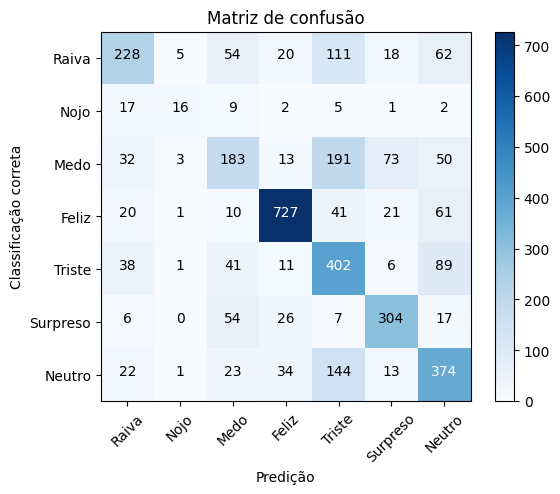

In [51]:
import itertools
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues) # criando a imagem de matriz
plt.title(titulo) # titulo
plt.colorbar() # barra de cores
tick_marks = np.arange(len(expressoes)) # tamamho de acordo com a quantidade de emocoes
plt.xticks(tick_marks, expressoes, rotation=45) # eixo x(classes)
plt.yticks(tick_marks, expressoes); # eixo y
fmt = 'd'
thresh = cm.max() / 2. # buscar o maior valor da matriz de confusão e dividir por 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])): # percoreendo a matriz acessando a linhas e as colunas
   plt.text(j,i, format(cm[i,j], fmt), horizontalalignment='center',color='white' if cm[i,j] > thresh else 'black') # preenchimento com texto na matriz
plt.ylabel('Classificação correta')
plt.xlabel('Predição')
plt.savefig('matriz_confusao_mod01.png') # salvar a figura

## Testando modelo

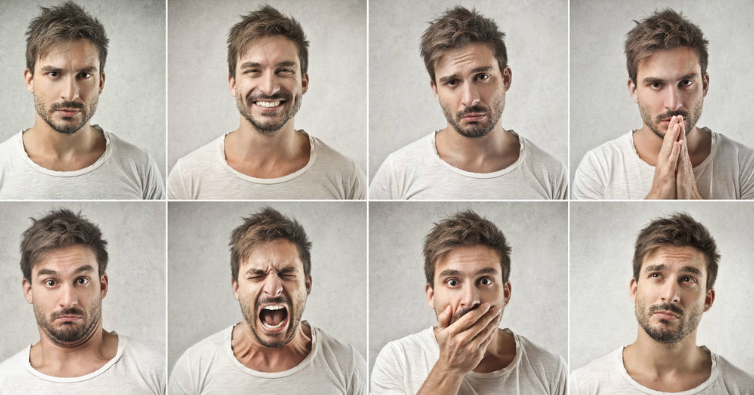

In [52]:
imagem = cv2.imread('Material/testes/teste02.jpg') # leitura da imagem
cv2_imshow(imagem) # mostra a imagem

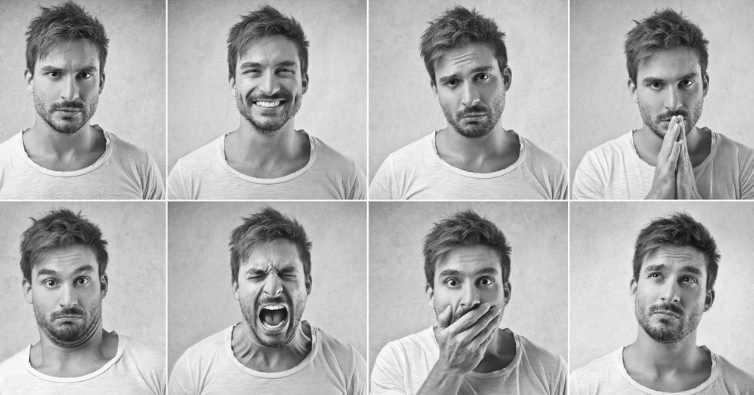

In [53]:
original = imagem.copy() # copia a imagem
gray = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY) # imagem cinza
cv2_imshow(gray) # mostra a imagem cinza

In [54]:
face_cascade = cv2.CascadeClassifier('Material/haarcascade_frontalface_default.xml') # carregando o classificador
faces = face_cascade.detectMultiScale(gray, 1.1, 3) # detecção da face

In [55]:
faces

array([[224,  35,  90,  90],
       [625,  49,  91,  91],
       [ 23,  41,  92,  92],
       [420,  43,  97,  97],
       [420, 242,  97,  97],
       [ 18, 243,  98,  98],
       [229, 242,  85,  85],
       [627, 241,  91,  91]], dtype=int32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


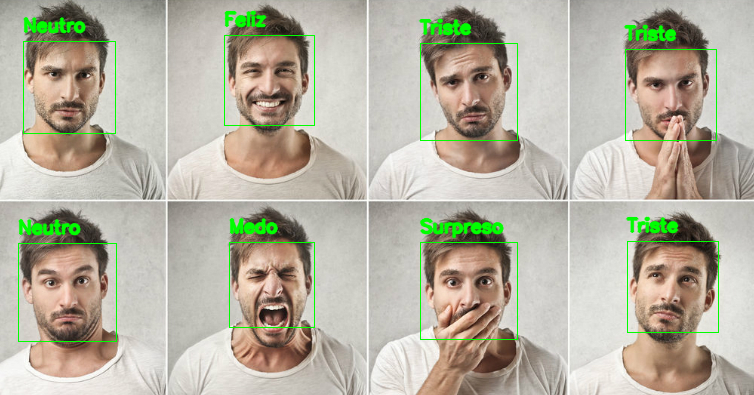

In [56]:
for(x,y,w,h) in faces:
  cv2.rectangle(original, (x,y), (x+w, y+h), (0,255,0), 1)
  roi_gray = gray[y:y+h, x:x+w]
  roi_gray = roi_gray.astype('float') / 255.0 # transformando em float, depois dividindo para ficar 0 e 1
  cropped_img = np.expand_dims(np.expand_dims(cv2.resize(roi_gray, (48,48)), -1), 0) # expandindo a dimensao
  prediction = loaded_model.predict(cropped_img)[0] # fazendo a predição
  cv2.putText(original, expressoes[int(np.argmax(prediction))], (x,y -10),
              cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2, cv2.LINE_AA)
cv2_imshow(original)